# 01 — Generate Synthetic YOLO Instance Segmentation Dataset

Generate a YOLO instance segmentation dataset for **IQ Noodles** pieces using BlenderProc.

**Input:** `IQ-Noodles.stl`

**Output:** `data/noodles_seg_dataset/` with images, labels, dataset.yaml, preview.jpg

**Architecture rule:** This notebook never imports `blenderproc`. All BlenderProc logic lives in `blenderproc_scene_generator.py`, called via subprocess.

## Section 0 — Dependencies & Config

In [ ]:
# Install required packages (uncomment as needed)
# !pip install -q "blenderproc>=2.7.0" "trimesh>=4.0.0" numpy opencv-python-headless Pillow matplotlib tqdm pyyaml requests

import os
import json
import random
import subprocess
import math
from pathlib import Path

import numpy as np
import cv2
import trimesh
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Project root (auto-detect from notebook location) ────────────────────────
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
print(f"Project root: {PROJECT_ROOT}")

# ── Paths (all under data/) ──────────────────────────────────────────────────
DATA_DIR = PROJECT_ROOT / 'data'
STL_PATH = DATA_DIR / 'raw' / 'IQ-Noodles.stl'
PIECE_OBJS_DIR = DATA_DIR / 'piece_objs'
HDRI_DIR = DATA_DIR / 'hdri'
DATASET_DIR = DATA_DIR / 'noodles_seg_dataset'
GENERATOR_SCRIPT = PROJECT_ROOT / 'blenderproc_scene_generator.py'

# ── If STL is at project root, copy it to data/raw/ ─────────────────────────
STL_AT_ROOT = PROJECT_ROOT / 'IQ-Noodles.stl'
if not STL_PATH.exists() and STL_AT_ROOT.exists():
    STL_PATH.parent.mkdir(parents=True, exist_ok=True)
    import shutil
    shutil.copy2(STL_AT_ROOT, STL_PATH)
    print(f"Copied STL to {STL_PATH}")

assert STL_PATH.exists(), f"STL not found at {STL_PATH}"
assert GENERATOR_SCRIPT.exists(), f"Generator script not found at {GENERATOR_SCRIPT}"

# ── Config ────────────────────────────────────────────────────────────────────
IMG_SIZE = 640
NUM_TRAIN_IMAGES = 800
NUM_VAL_IMAGES = 200
MIN_PIECES_PER_IMAGE = 2
MAX_PIECES_PER_IMAGE = 8
FORCE_ALL_PIECES = True
RENDER_BOARD = False
FORCE_GRID_LAYOUT = True
GRID_ROWS = 3
GRID_COLS = 4
GRID_JITTER_REL = 0.003
STRICT_GRID_MODE = True
PLACEMENT_SCALE = 1.35
PIECE_ONLY_SPAN = 0.32
PIECE_SCALE = 0.00143
CYCLES_SAMPLES = 32
USE_GPU = True

# ── Ground-truth colors (final approved index -> color mapping) ──────────────
PIECE_COLORS = {
    'A': ('Yellow',      (0xF9, 0xD6, 0x5E)),  # 0
    'B': ('SkyBlue',     (0x08, 0xA7, 0xE8)),  # 1
    'C': ('DarkBlue',    (0x20, 0x6D, 0xD9)),  # 2
    'D': ('Green',       (0x1F, 0xA1, 0x5B)),  # 3
    'E': ('Red',         (0xEE, 0x39, 0x4F)),  # 4
    'F': ('Teal',        (0x85, 0xDA, 0xBB)),  # 5
    'G': ('Pink',        (0xEC, 0x71, 0xA8)),  # 6
    'H': ('Purple',      (0xC7, 0x78, 0xB9)),  # 7
    'I': ('Orange',      (0xFC, 0x69, 0x0C)),  # 8
    'J': ('DarkRed',     (0xB6, 0x30, 0x48)),  # 9
    'K': ('YellowGreen', (0x95, 0xD4, 0x50)),  # 10
}

# Deterministic label/index order (never rely on dict iteration order)
PIECE_LABELS = sorted(PIECE_COLORS.keys())
FACE_SORTED_LABELS = ['J', 'H', 'C', 'A', 'E', 'D', 'B', 'I', 'G', 'K', 'F']

PIECE_COLORS_LINEAR = {
    lbl: tuple(ch / 255.0 for ch in rgb)
    for lbl, (_, rgb) in PIECE_COLORS.items()
}

LABEL_TO_CLASS_ID = {label: i for i, label in enumerate(PIECE_LABELS)}
CLASS_ID_TO_LABEL = {i: label for label, i in LABEL_TO_CLASS_ID.items()}
CLASS_NAMES = {i: f"{lbl}_{PIECE_COLORS[lbl][0]}" for i, lbl in enumerate(PIECE_LABELS)}

print("\n✅ Config loaded")
print(f"   STL:           {STL_PATH}")
print(f"   Dataset dir:   {DATASET_DIR}")
print(f"   Generator:     {GENERATOR_SCRIPT}")
print(f"   Images:        {NUM_TRAIN_IMAGES} train + {NUM_VAL_IMAGES} val")
print(f"   Pieces/image:  {MIN_PIECES_PER_IMAGE}–{MAX_PIECES_PER_IMAGE}")
print(f"   Force all:     {FORCE_ALL_PIECES}")
print(f"   Render board:  {RENDER_BOARD}")
print(f"   Grid layout:   {FORCE_GRID_LAYOUT} ({GRID_ROWS}x{GRID_COLS})")
print(f"   Strict grid:   {STRICT_GRID_MODE}")
print(f"   Place scale:   {PLACEMENT_SCALE}")
print(f"   Piece span:    {PIECE_ONLY_SPAN}")
print(f"   Piece scale:   {PIECE_SCALE}")

print("\nindex  piece  color_name     hex")
for i, label in enumerate(PIECE_LABELS):
    color_name, rgb = PIECE_COLORS[label]
    print(f"{i:<5}  {label:<5}  {color_name:<12}  #{rgb[0]:02X}{rgb[1]:02X}{rgb[2]:02X}")

Project root: /home/salumi/projects/project

✅ Config loaded
   STL:           /home/salumi/projects/project/data/raw/IQ-Noodles.stl
   Dataset dir:   /home/salumi/projects/project/data/noodles_seg_dataset
   Generator:     /home/salumi/projects/project/blenderproc_scene_generator.py
   Images:        800 train + 200 val
   Pieces/image:  2–8
   Force all:     True
   Render board:  False
   Grid layout:   True (3x4)
   Strict grid:   True
   Place scale:   1.35
   Piece span:    0.32
   Piece scale:   0.00135

index  piece  color_name     hex
0      A      YellowGreen   #95D450
1      B      Red           #EE394F
2      C      DarkBlue      #206DD9
3      D      Purple        #C778B9
4      E      Orange        #FC690C
5      F      SkyBlue       #08A7E8
6      G      Green         #1FA15B
7      H      DarkRed       #B63048
8      I      Yellow        #F9D65E
9      J      Pink          #EC71A8
10     K      Teal          #85DABB


## Section 1 — STL Loading & OBJ Export

In [5]:
# ── Load the STL ──────────────────────────────────────────────────────────────
mesh = trimesh.load(str(STL_PATH))
print(f"Mesh type: {type(mesh).__name__}")

# ── Split into components ─────────────────────────────────────────────────────
if isinstance(mesh, trimesh.Trimesh):
    components = mesh.split(only_watertight=False)
elif isinstance(mesh, trimesh.Scene):
    components = []
    for name, geom in mesh.geometry.items():
        if isinstance(geom, trimesh.Trimesh):
            components.extend(geom.split(only_watertight=False))
else:
    raise ValueError(f"Unexpected mesh type: {type(mesh)}")

print(f"Total components: {len(components)}")

# ── Classify: board / artifact / piece ─────────────────────────────────────────
board_parts = []
piece_parts = []
artifact_count = 0

for comp in components:
    ext = comp.extents
    if ext.max() > 80:
        board_parts.append(comp)
        print(f"  [board] {len(comp.vertices)} verts, extents={np.round(ext, 1)}")
    elif len(comp.faces) < 100 or ext.min() < 1.0:
        artifact_count += 1
        print(f"  [skip]  {len(comp.faces)} faces, extents={np.round(ext, 1)}")
    else:
        piece_parts.append(comp)

print(f"\n  Board parts: {len(board_parts)}, Artifacts: {artifact_count}, Pieces: {len(piece_parts)}")

# ── Combine board ─────────────────────────────────────────────────────────────
assert len(board_parts) > 0, "No board parts found!"
board_mesh = trimesh.util.concatenate(board_parts)
print(f"  Board mesh: {len(board_mesh.vertices)} verts, {len(board_mesh.faces)} faces")

# ── Assert exactly 11 pieces ──────────────────────────────────────────────────
assert len(piece_parts) == 11, f"Expected 11 pieces, got {len(piece_parts)}"

# ── Sort by face count and map to labels ──────────────────────────────────────
piece_parts.sort(key=lambda p: len(p.faces))
label_to_piece = dict(zip(FACE_SORTED_LABELS, piece_parts))
pieces = [label_to_piece[label] for label in PIECE_LABELS]  # reorder to A-K

# ── Save board extents ────────────────────────────────────────────────────────
BOARD_EXTENTS_MM = board_mesh.extents
BOARD_BOUNDS_MM = board_mesh.bounds
THICKNESS_AXIS_MM = int(np.argmin(BOARD_EXTENTS_MM))
PLANAR_AXES_MM = [ax for ax in [0, 1, 2] if ax != THICKNESS_AXIS_MM]
print(f"  Board extents (mm): {np.round(BOARD_EXTENTS_MM, 1)}")
print(f"  Board bounds  (mm): min={np.round(BOARD_BOUNDS_MM[0], 1)}, max={np.round(BOARD_BOUNDS_MM[1], 1)}")
print(f"  Thickness axis: {THICKNESS_AXIS_MM}, planar axes: {PLANAR_AXES_MM}")

# ── Export OBJ files ──────────────────────────────────────────────────────────
PIECE_OBJS_DIR.mkdir(parents=True, exist_ok=True)

for i, label in enumerate(PIECE_LABELS):
    obj_path = PIECE_OBJS_DIR / f"piece_{label}.obj"
    pieces[i].export(str(obj_path))

board_obj_path = PIECE_OBJS_DIR / 'board.obj'
board_mesh.export(str(board_obj_path))

# ── Verify all files exist ────────────────────────────────────────────────────
for label in PIECE_LABELS:
    assert (PIECE_OBJS_DIR / f"piece_{label}.obj").exists(), f"Missing piece_{label}.obj"
assert board_obj_path.exists(), "Missing board.obj"

# ── Print summary ─────────────────────────────────────────────────────────────
print(f"\n✅ Exported {len(PIECE_LABELS)} pieces + board to {PIECE_OBJS_DIR}")
print(f"{'Label':<6} {'Faces':<8} {'Extents':<30} {'Color'}")
print('-' * 70)
for i, label in enumerate(PIECE_LABELS):
    p = pieces[i]
    color = PIECE_COLORS_LINEAR[label]
    print(f"{label:<6} {len(p.faces):<8} {str(np.round(p.extents, 1)):<30} {color}")

Mesh type: Trimesh
Total components: 14
  [board] 128866 verts, extents=[141.8  19.2 141.6]
  [board] 458151 verts, extents=[141.8  18.9 140. ]
  [skip]  2 faces, extents=[26.3  0.   7.2]

  Board parts: 2, Artifacts: 1, Pieces: 11
  Board mesh: 587017 verts, 1174034 faces
  Board extents (mm): [141.8  19.2 141.6]
  Board bounds  (mm): min=[-70.9  -9.5  -9.5], max=[ 70.9   9.8 132.1]
  Thickness axis: 1, planar axes: [0, 2]

✅ Exported 11 pieces + board to /home/salumi/projects/project/data/piece_objs
Label  Faces    Extents                        Color
----------------------------------------------------------------------
A      28360    [41.   9.9 41. ]               (0.9764705882352941, 0.8392156862745098, 0.3686274509803922)
B      28664    [41.   9.9 36.5]               (0.03137254901960784, 0.6549019607843137, 0.9098039215686274)
C      24951    [51.6  9.9 15.1]               (0.12549019607843137, 0.42745098039215684, 0.8509803921568627)
D      28608    [25.8  9.9 51.6]          

In [ ]:
# Visual checkpoint: piece extraction sanity (per-piece top-down)
# This view is easier to inspect than plotting all pieces on top of each other.
u_axis, v_axis = PLANAR_AXES_MM[0], PLANAR_AXES_MM[1]

piece_previews = [
    trimesh.load(str(PIECE_OBJS_DIR / f"piece_{lbl}.obj"), force='mesh')
    for lbl in PIECE_LABELS
]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i, (lbl, mesh_p) in enumerate(zip(PIECE_LABELS, piece_previews)):
    verts_uv = mesh_p.vertices[:, [u_axis, v_axis]].astype(np.float32)
    verts_uv -= verts_uv.mean(axis=0, keepdims=True)

    axes[i].scatter(verts_uv[:, 0], verts_uv[:, 1], s=0.3, alpha=0.35, c='tab:blue')
    axes[i].set_title(f"{lbl}  ext={np.round(mesh_p.extents, 1)}", fontsize=9)
    axes[i].set_aspect('equal', adjustable='box')
    axes[i].grid(alpha=0.2)

for j in range(len(PIECE_LABELS), len(axes)):
    axes[j].axis('off')

plt.suptitle('Piece extraction sanity (individual pieces, centered)', fontsize=13)
plt.tight_layout()
plt.show()

print('✅ Piece extraction sanity check complete')

## Section 2 — HDRI Setup

In [ ]:
import requests

HDRI_DIR.mkdir(parents=True, exist_ok=True)
hdr_files = sorted(HDRI_DIR.glob('**/*.hdr'))

if not hdr_files:
    WANT_HDRIS = ['studio_small_08', 'abandoned_workshop_02', 'evening_road_01']
    
    for name in WANT_HDRIS:
        out_path = HDRI_DIR / f"{name}.hdr"
        if out_path.exists():
            continue
        try:
            # Get download URL from Poly Haven API
            info = requests.get(f"https://api.polyhaven.com/files/{name}", timeout=10).json()
            url = info['hdri']['2k']['hdr']['url']
            print(f"Downloading {name}...")
            r = requests.get(url, timeout=120, stream=True)
            with open(out_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
            print(f"  ✅ {out_path.name}")
        except Exception as e:
            print(f"  ⚠️ Failed to download {name}: {e}")

    hdr_files = sorted(HDRI_DIR.glob('**/*.hdr'))

# If still nothing, fall back to procedural (keeps existing fallback logic)
if not hdr_files:
    print("Falling back to procedural HDRIs...")
    # ... existing make_procedural_hdri code ...

print(f"\n✅ HDRI count: {len(hdr_files)}")
for f in hdr_files[:5]:
    print(f"  {f.name}")


In [ ]:
# Visual checkpoint: HDRI quick preview
preview_hdrs = hdr_files[:3]
if not preview_hdrs:
    print('⚠️ No HDRIs found to preview.')
else:
    fig, axes = plt.subplots(1, len(preview_hdrs), figsize=(6 * len(preview_hdrs), 3))
    if len(preview_hdrs) == 1:
        axes = [axes]

    for ax, hdr_path in zip(axes, preview_hdrs):
        hdr = cv2.imread(str(hdr_path), cv2.IMREAD_UNCHANGED)
        if hdr is None:
            ax.set_title(f'{hdr_path.name}\n(load failed)')
            ax.axis('off')
            continue

        hdr = hdr.astype(np.float32)
        scale = float(np.percentile(hdr, 99)) + 1e-6
        ldr = np.clip(hdr / scale, 0, 1) ** (1 / 2.2)
        ldr = cv2.cvtColor(ldr, cv2.COLOR_BGR2RGB)

        ax.imshow(ldr)
        ax.set_title(hdr_path.name, fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    print(f"✅ HDRI previewed: {[p.name for p in preview_hdrs]}")

## Section 3 — Placement Generator

In [ ]:
def _piece_half_size_rel(label, rot_z_deg):
    """Approximate piece half-size in placement relative coordinates."""
    mesh = label_to_piece[label]
    ext = mesh.extents.astype(np.float32)

    u_axis, v_axis = PLANAR_AXES_MM[0], PLANAR_AXES_MM[1]
    ext_u_mm = float(ext[u_axis])
    ext_v_mm = float(ext[v_axis])

    if int(rot_z_deg) % 180 == 90:
        ext_u_mm, ext_v_mm = ext_v_mm, ext_u_mm

    half_u = (ext_u_mm * PIECE_SCALE) / (2.0 * PIECE_ONLY_SPAN)
    half_v = (ext_v_mm * PIECE_SCALE) / (2.0 * PIECE_ONLY_SPAN)
    return half_u, half_v


def generate_placements(num_pieces, _board_bounds_mm, _board_extents_mm, seed=None):
    """Deterministic non-overlapping near-full-frame grid placement."""
    _ = (_board_bounds_mm, _board_extents_mm)
    rng = random.Random(seed) if seed is not None else random

    if FORCE_ALL_PIECES:
        chosen_labels = PIECE_LABELS.copy()
    else:
        n = min(num_pieces, len(PIECE_LABELS))
        chosen_labels = rng.sample(PIECE_LABELS, n)

    n = len(chosen_labels)
    if FORCE_GRID_LAYOUT:
        n_rows, n_cols = GRID_ROWS, GRID_COLS
    else:
        n_cols = int(math.ceil(math.sqrt(n)))
        n_rows = int(math.ceil(n / n_cols))

    if n > n_rows * n_cols:
        raise ValueError(f"Grid capacity too small: pieces={n}, capacity={n_rows*n_cols}")

    frame_min, frame_max = -0.46, 0.46
    frame_span = frame_max - frame_min
    cell_w = frame_span / n_cols
    cell_h = frame_span / n_rows
    pad = 0.009

    cell_indices = [(r, c) for r in range(n_rows) for c in range(n_cols)]
    rng.shuffle(cell_indices)

    placements = []
    for i, label in enumerate(chosen_labels):
        row, col = cell_indices[i]
        cell_u_min = frame_min + col * cell_w
        cell_u_max = frame_min + (col + 1) * cell_w
        cell_v_min = frame_min + row * cell_h
        cell_v_max = frame_min + (row + 1) * cell_h

        placed = None
        for _ in range(24):
            rot_z_deg = rng.choice([0.0, 90.0, 180.0, 270.0])
            flip_x = rng.random() < 0.5
            flip_y = rng.random() < 0.5
            half_u, half_v = _piece_half_size_rel(label, rot_z_deg)

            u_low = cell_u_min + half_u + pad
            u_high = cell_u_max - half_u - pad
            v_low = cell_v_min + half_v + pad
            v_high = cell_v_max - half_v - pad
            if u_low > u_high or v_low > v_high:
                continue

            pos_u = float(rng.uniform(u_low, u_high))
            pos_v = float(rng.uniform(v_low, v_high))

            if not (cell_u_min <= pos_u - half_u <= pos_u + half_u <= cell_u_max):
                continue
            if not (cell_v_min <= pos_v - half_v <= pos_v + half_v <= cell_v_max):
                continue
            if not (frame_min <= pos_u - half_u and pos_u + half_u <= frame_max):
                continue
            if not (frame_min <= pos_v - half_v and pos_v + half_v <= frame_max):
                continue

            placed = {
                'label': label,
                'class_id': LABEL_TO_CLASS_ID[label] + 1,
                'pos_u': pos_u,
                'pos_v': pos_v,
                'rot_z_deg': rot_z_deg,
                'flip_x': flip_x,
                'flip_y': flip_y,
            }
            break

        if placed is None:
            raise ValueError(
                f"No feasible placement in grid cell for piece {label} at current PIECE_SCALE={PIECE_SCALE}"
            )
        placements.append(placed)

    for p in placements:
        expected = LABEL_TO_CLASS_ID[p['label']] + 1
        if p['class_id'] != expected:
            raise AssertionError(f"Class mapping drift detected for {p['label']}: {p['class_id']} != {expected}")

    return placements


# Quick test
test_seed = 12345
test_placements = generate_placements(3, BOARD_BOUNDS_MM, BOARD_EXTENTS_MM, seed=test_seed)
for p in test_placements:
    print(
        f"  {p['label']} (class {p['class_id']}): rel_u={p['pos_u']:.4f}, rel_v={p['pos_v']:.4f}, "
        f"rot={p['rot_z_deg']:.1f}°, flip_x={p['flip_x']}, flip_y={p['flip_y']}"
    )
print("\n✅ Placement generator ready")

  A (class 1): rel_u=0.3482, rel_v=0.2736, rot=270.0°, flip_x=True, flip_y=False
  B (class 2): rel_u=0.1175, rel_v=0.2647, rot=0.0°, flip_x=False, flip_y=False
  C (class 3): rel_u=-0.3679, rel_v=0.2791, rot=90.0°, flip_x=False, flip_y=True
  D (class 4): rel_u=-0.0965, rel_v=-0.3116, rot=180.0°, flip_x=True, flip_y=False
  E (class 5): rel_u=0.3069, rel_v=0.0105, rot=90.0°, flip_x=True, flip_y=False
  F (class 6): rel_u=-0.1143, rel_v=0.3188, rot=90.0°, flip_x=False, flip_y=True
  G (class 7): rel_u=0.1333, rel_v=-0.3501, rot=180.0°, flip_x=False, flip_y=True
  H (class 8): rel_u=0.3853, rel_v=-0.3457, rot=90.0°, flip_x=True, flip_y=True
  I (class 9): rel_u=-0.1120, rel_v=-0.0199, rot=0.0°, flip_x=True, flip_y=True
  J (class 10): rel_u=-0.3477, rel_v=-0.0194, rot=180.0°, flip_x=True, flip_y=True
  K (class 11): rel_u=-0.3488, rel_v=-0.2757, rot=90.0°, flip_x=False, flip_y=False

✅ Placement generator ready


In [ ]:
# Visual checkpoint: placement distribution preview
sample_count = 120
preview_places = generate_placements(sample_count, BOARD_BOUNDS_MM, BOARD_EXTENTS_MM)

us = [p['pos_u'] for p in preview_places]
vs = [p['pos_v'] for p in preview_places]

fig, ax = plt.subplots(figsize=(6, 6))
ax.add_patch(
    plt.Rectangle(
        (-0.5, -0.5),
        1.0,
        1.0,
        fill=False,
        edgecolor='black',
        linewidth=2,
        label='relative frame',
    )
)

if FORCE_GRID_LAYOUT:
    grid_u = np.linspace(-0.40, 0.40, GRID_COLS)
    grid_v = np.linspace(-0.40, 0.40, GRID_ROWS)
    for u in grid_u:
        ax.axvline(u, color='gray', alpha=0.15, linewidth=1)
    for v in grid_v:
        ax.axhline(v, color='gray', alpha=0.15, linewidth=1)

ax.scatter(us, vs, s=24, alpha=0.8, c='tab:blue')
ax.set_title('Placement distribution sanity check')
ax.set_xlabel('relative u')
ax.set_ylabel('relative v')
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

if len(preview_places) >= 2:
    points = np.array([[p['pos_u'], p['pos_v']] for p in preview_places], dtype=np.float32)
    dists = []
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            dists.append(float(np.linalg.norm(points[i] - points[j])))
    print(f"Minimum pair distance (relative): {min(dists):.4f}")

print(f"✅ Placement checkpoint: {sample_count} samples")

## Section 4 — Dataset Generation Loop

✅ Smoke succeeded on try 3/10


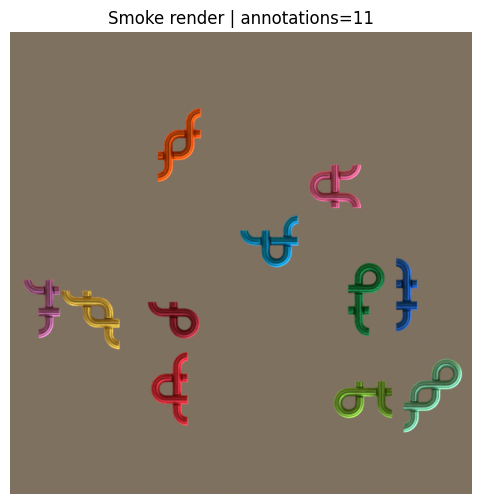

--- BlenderProc stderr tail ---
[INFO] Board center=[0.0, -0.06128999963402748, 0.00013000000035390258] extents=[0.14180000126361847, 0.1415800005197525, 0.01924999989569187] thickness_axis=2 planar_axes=[0, 1]
[DEBUG] Mask render device: GPU
[DEBUG] Mask render device: GPU
[DEBUG] Mask render device: GPU
[DEBUG] Mask render device: GPU
[DEBUG] Mask render device: GPU
[DEBUG] Mask render device: GPU
[DEBUG] Mask render device: GPU
[WARN] Reduced tilt scale to 0.50 to satisfy render-space layout
[INFO] Saved image=/home/salumi/projects/project/data/noodles_seg_dataset/images/train/smoke_train_00000.png annotations=11 pieces=11

✅ Smoke render complete: smoke_train_00000.png, anns=11


In [ ]:
# Visual checkpoint: single-image smoke test before full generation
smoke_idx = 0
smoke_split = 'train'

smoke_img_name = f"smoke_{smoke_split}_{smoke_idx:05d}.png"
smoke_json_name = f"smoke_{smoke_split}_{smoke_idx:05d}.json"
smoke_output_img = DATASET_DIR / 'images' / smoke_split / smoke_img_name
smoke_output_json = DATASET_DIR / 'tmp' / smoke_json_name
smoke_label_path = DATASET_DIR / 'labels' / smoke_split / f"smoke_{smoke_split}_{smoke_idx:05d}.txt"
smoke_args_file = DATASET_DIR / 'tmp' / f"args_smoke_{smoke_split}_{smoke_idx:05d}.json"

smoke_output_img.parent.mkdir(parents=True, exist_ok=True)
smoke_output_json.parent.mkdir(parents=True, exist_ok=True)
smoke_label_path.parent.mkdir(parents=True, exist_ok=True)
smoke_args_file.parent.mkdir(parents=True, exist_ok=True)

smoke_env = os.environ.copy()
smoke_env['CYCLES_DEVICE'] = 'OPTIX'
smoke_env['MPLBACKEND'] = 'Agg'

smoke_n_pieces = random.randint(max(3, MIN_PIECES_PER_IMAGE), max(4, MIN_PIECES_PER_IMAGE + 2))
if FORCE_ALL_PIECES:
    smoke_n_pieces = len(PIECE_LABELS)

smoke_hdrs = sorted(HDRI_DIR.glob('**/*.hdr'))
if not smoke_hdrs:
    raise RuntimeError(f"No .hdr files found in {HDRI_DIR}. Run Section 2 first.")


def _all_annotations_have_margin(annotation_lines, margin=0.012):
    for ln in annotation_lines:
        parts = ln.strip().split()
        if len(parts) < 9 or (len(parts) - 1) % 2 != 0:
            return False

        vals = [float(v) for v in parts[1:]]
        xs = vals[0::2]
        ys = vals[1::2]
        if not xs or not ys:
            return False
        if min(xs) < margin or max(xs) > 1.0 - margin:
            return False
        if min(ys) < margin or max(ys) > 1.0 - margin:
            return False
    return True


MAX_SMOKE_TRIES = 10
smoke_result = None
ann_lines = []
last_err = None

for smoke_try in range(1, MAX_SMOKE_TRIES + 1):
    smoke_seed = random.randint(1, 2_147_483_647)
    smoke_args = {
        'piece_obj_paths': {lbl: str(PIECE_OBJS_DIR / f"piece_{lbl}.obj") for lbl in PIECE_LABELS},
        'board_obj_path': str(PIECE_OBJS_DIR / 'board.obj'),
        'output_img_path': str(smoke_output_img),
        'output_json_path': str(smoke_output_json),
        'hdri_path': str(random.choice(smoke_hdrs)),
        'num_pieces': smoke_n_pieces,
        'img_size': IMG_SIZE,
        'cycles_samples': CYCLES_SAMPLES,
        'use_gpu': USE_GPU,
        'render_board': RENDER_BOARD,
        'placement_mode': 'relative',
        'placement_scale': PLACEMENT_SCALE,
        'piece_only_span': PIECE_ONLY_SPAN,
        'piece_scale': PIECE_SCALE,
        'max_tilt_deg': 6.0,
        'layout_overlap_pixel_threshold': 8,
        'internal_piece_class_offset': 1,
        'seed': smoke_seed,
        'piece_placements': generate_placements(
            smoke_n_pieces, BOARD_BOUNDS_MM, BOARD_EXTENTS_MM, seed=smoke_seed
        ),
    }

    with open(smoke_args_file, 'w') as f:
        json.dump(smoke_args, f)

    smoke_cmd = ['blenderproc', 'run', str(GENERATOR_SCRIPT), str(smoke_args_file)]
    smoke_result = subprocess.run(smoke_cmd, capture_output=True, text=True, timeout=180, env=smoke_env)

    if smoke_result.returncode != 0:
        last_err = smoke_result.stderr[-800:]
        continue

    ann_lines = []
    if smoke_output_json.exists():
        with open(smoke_output_json) as f:
            ann_lines = json.load(f).get('annotations', [])

    if not ann_lines:
        last_err = 'empty_annotations'
        continue
    if len(ann_lines) != smoke_n_pieces:
        last_err = f"missing_annotations: got={len(ann_lines)} expected={smoke_n_pieces}"
        continue
    if not _all_annotations_have_margin(ann_lines, margin=0.012):
        last_err = 'edge_clipping_detected'
        continue

    print(f"✅ Smoke succeeded on try {smoke_try}/{MAX_SMOKE_TRIES}")
    break

if smoke_result is None or smoke_result.returncode != 0 or not ann_lines:
    print('❌ Smoke render failed after retries')
    print(last_err if last_err else '(no error text)')
    if smoke_result is not None:
        print(smoke_result.stderr[-2000:])
else:
    with open(smoke_label_path, 'w') as f:
        for line in ann_lines:
            f.write(line + '\n')

    smoke_img = cv2.imread(str(smoke_output_img))
    if smoke_img is None:
        print('❌ Smoke image not readable')
    else:
        smoke_img = cv2.cvtColor(smoke_img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6, 6))
        plt.imshow(smoke_img)
        plt.title(f'Smoke render | annotations={len(ann_lines)}')
        plt.axis('off')
        plt.show()

    print('--- BlenderProc stderr tail ---')
    print(smoke_result.stderr[-1200:])
    print(f"✅ Smoke render complete: {smoke_output_img.name}, anns={len(ann_lines)}")

if smoke_args_file.exists():
    smoke_args_file.unlink()
if smoke_output_json.exists():
    smoke_output_json.unlink()

Annotations in smoke label file: 11
Unique classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Expected classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Missing classes: none
  class  0 (A_Yellow): 1
  class  1 (B_SkyBlue): 1
  class  2 (C_DarkBlue): 1
  class  3 (D_Green): 1
  class  4 (E_Red): 1
  class  5 (F_Teal): 1
  class  6 (G_Pink): 1
  class  7 (H_Purple): 1
  class  8 (I_Orange): 1
  class  9 (J_DarkRed): 1
  class 10 (K_YellowGreen): 1


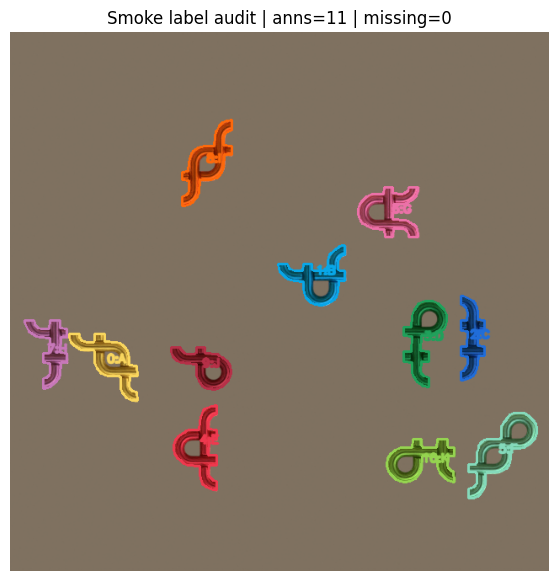

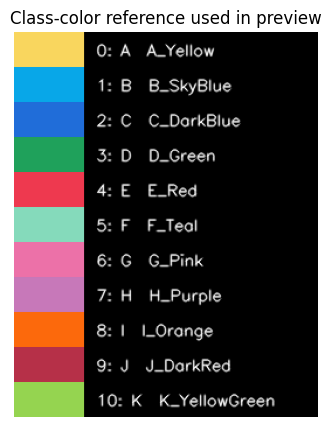

✅ Smoke label audit complete


In [10]:
# Visual checkpoint: smoke label audit (class correctness + color sanity)
from collections import Counter

smoke_img = cv2.imread(str(smoke_output_img))
if smoke_img is None:
    print('❌ Smoke image not found for audit')
else:
    smoke_img = cv2.cvtColor(smoke_img, cv2.COLOR_BGR2RGB)
    h, w = smoke_img.shape[:2]

    parsed_lines = []
    if smoke_label_path.exists():
        for raw_line in smoke_label_path.read_text().splitlines():
            line = raw_line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 9:
                continue
            cls_id = int(parts[0])
            coords = [float(v) for v in parts[1:]]
            parsed_lines.append((cls_id, coords))

    present = sorted({cls for cls, _ in parsed_lines})
    expected = list(range(len(PIECE_LABELS))) if FORCE_ALL_PIECES else sorted(set(present))
    missing = [c for c in expected if c not in present]

    print(f'Annotations in smoke label file: {len(parsed_lines)}')
    print(f'Unique classes present: {present}')
    if FORCE_ALL_PIECES:
        print(f'Expected classes: {expected}')
        print(f'Missing classes: {missing if missing else "none"}')

    class_counts = Counter(cls for cls, _ in parsed_lines)
    for cls_id in sorted(class_counts):
        print(f"  class {cls_id:2d} ({CLASS_NAMES.get(cls_id, '?')}): {class_counts[cls_id]}")

    preview = smoke_img.copy()
    palette_rgb = [tuple(int(255 * c) for c in PIECE_COLORS_LINEAR[lbl]) for lbl in PIECE_LABELS]

    for cls_id, coords in parsed_lines:
        pts = []
        for i in range(0, len(coords), 2):
            x = int(np.clip(coords[i], 0, 1) * (w - 1))
            y = int(np.clip(coords[i + 1], 0, 1) * (h - 1))
            pts.append([x, y])
        pts = np.array(pts, dtype=np.int32)
        color = palette_rgb[cls_id % len(palette_rgb)]
        cv2.polylines(preview, [pts], True, color, 2)

        centroid = pts.mean(axis=0).astype(int)
        label_txt = f"{cls_id}:{PIECE_LABELS[cls_id]}" if cls_id < len(PIECE_LABELS) else str(cls_id)
        cv2.putText(
            preview,
            label_txt,
            (int(centroid[0]), int(centroid[1])),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            color,
            2,
            cv2.LINE_AA,
        )

    plt.figure(figsize=(7, 7))
    plt.imshow(preview)
    plt.title(f'Smoke label audit | anns={len(parsed_lines)} | missing={len(missing)}')
    plt.axis('off')
    plt.show()

    swatch_h = 30
    swatch = np.zeros((swatch_h * len(PIECE_LABELS), 260, 3), dtype=np.uint8)
    for i, lbl in enumerate(PIECE_LABELS):
        color = np.array(palette_rgb[i], dtype=np.uint8)
        swatch[i * swatch_h:(i + 1) * swatch_h, 0:60] = color
        txt = f"{i}: {lbl}  {CLASS_NAMES.get(i, '')}"
        cv2.putText(swatch, txt, (70, i * swatch_h + 20), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

    plt.figure(figsize=(7, 5))
    plt.imshow(swatch)
    plt.title('Class-color reference used in preview')
    plt.axis('off')
    plt.show()

    print('✅ Smoke label audit complete')

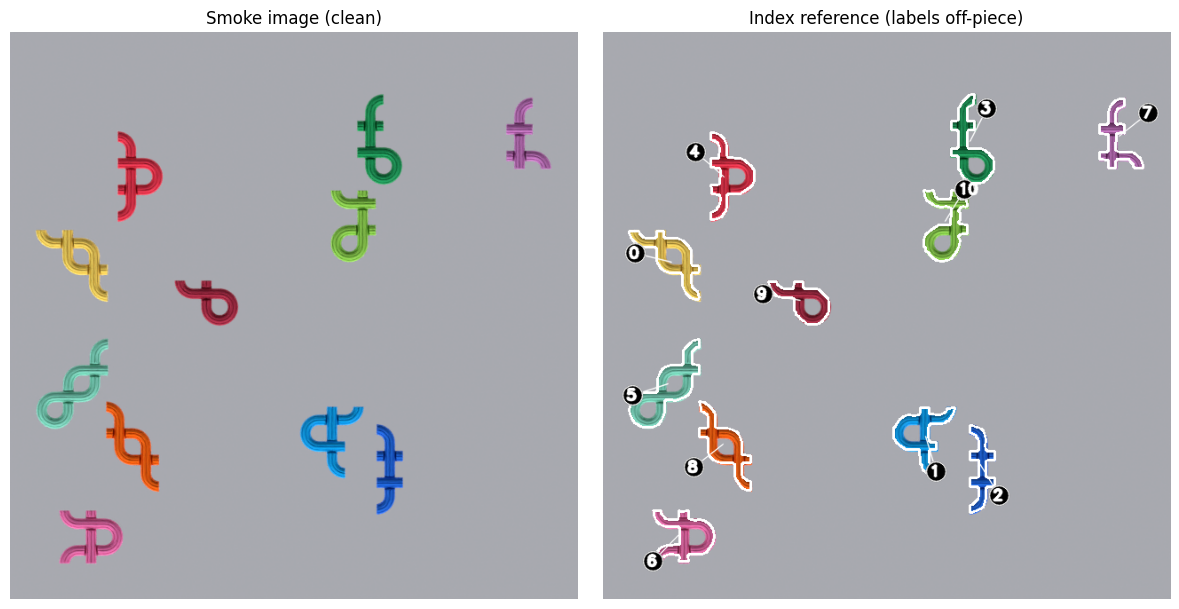

✅ Index reference saved: /home/salumi/projects/project/data/noodles_seg_dataset/tmp/smoke_index_reference.png
Index order reminder: 0:A, 1:B, 2:C, 3:D, 4:E, 5:F, 6:G, 7:H, 8:I, 9:J, 10:K


In [ ]:
# Visual checkpoint: index reference image (for manual color remap)
ref_img = cv2.imread(str(smoke_output_img))

if ref_img is None:
    print('❌ Smoke image not found for index reference')
else:
    ref_img = cv2.cvtColor(ref_img, cv2.COLOR_BGR2RGB)
    h, w = ref_img.shape[:2]

    idx_lines = []
    if smoke_label_path.exists():
        for raw_line in smoke_label_path.read_text().splitlines():
            line = raw_line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 9 or (len(parts) - 1) % 2 != 0:
                continue
            cls_id = int(parts[0])
            coords = [float(v) for v in parts[1:]]
            idx_lines.append((cls_id, coords))

    ref_overlay = ref_img.copy()
    img_center = np.array([w / 2.0, h / 2.0], dtype=np.float32)

    for cls_id, coords in idx_lines:
        pts = []
        for i in range(0, len(coords), 2):
            x = int(np.clip(coords[i], 0, 1) * (w - 1))
            y = int(np.clip(coords[i + 1], 0, 1) * (h - 1))
            pts.append([x, y])
        pts = np.array(pts, dtype=np.int32)
        if pts.shape[0] < 3:
            continue

        cv2.polylines(ref_overlay, [pts], True, (255, 255, 255), 2)

        centroid = pts.mean(axis=0).astype(np.float32)
        direction = centroid - img_center
        norm = float(np.linalg.norm(direction))
        if norm < 1e-5:
            direction = np.array([1.0, -1.0], dtype=np.float32)
            norm = float(np.linalg.norm(direction))
        direction = direction / norm

        label_pos = centroid + direction * 42.0
        lx = int(np.clip(label_pos[0], 16, w - 16))
        ly = int(np.clip(label_pos[1], 16, h - 16))
        cx, cy = int(centroid[0]), int(centroid[1])

        cv2.line(ref_overlay, (cx, cy), (lx, ly), (255, 255, 255), 1, cv2.LINE_AA)
        cv2.circle(ref_overlay, (lx, ly), 11, (0, 0, 0), -1, cv2.LINE_AA)
        cv2.circle(ref_overlay, (lx, ly), 11, (255, 255, 255), 1, cv2.LINE_AA)
        cv2.putText(
            ref_overlay,
            str(cls_id),
            (lx - 7, ly + 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

    ref_path = DATASET_DIR / 'tmp' / 'smoke_index_reference.png'
    ref_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(ref_path), cv2.cvtColor(ref_overlay, cv2.COLOR_RGB2BGR))

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(ref_img)
    axes[0].set_title('Smoke image (clean)')
    axes[0].axis('off')

    axes[1].imshow(ref_overlay)
    axes[1].set_title('Index reference (labels off-piece)')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    print(f'✅ Index reference saved: {ref_path}')
    print('Index order reminder: 0:A, 1:B, 2:C, 3:D, 4:E, 5:F, 6:G, 7:H, 8:I, 9:J, 10:K')

In [10]:
# Small-batch override for validation (fast check before full run)
SMALL_BATCH_TRAIN = 12
SMALL_BATCH_VAL = 4
NUM_TRAIN_IMAGES = SMALL_BATCH_TRAIN
NUM_VAL_IMAGES = SMALL_BATCH_VAL
print(f'✅ Small-batch override: train={NUM_TRAIN_IMAGES}, val={NUM_VAL_IMAGES}')

✅ Small-batch override: train=12, val=4


In [ ]:
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading

# ── GPU config ─────────────────────────────────────────────────────────────────
GPU_WORKERS = 1
MAX_RENDER_ATTEMPTS = 4
OVERLAP_PIXEL_THRESHOLD = 4

BLENDER_ENV = os.environ.copy()
BLENDER_ENV['MPLBACKEND'] = 'Agg'

# ── Create dataset directories ─────────────────────────────────────────────────
for split in ['train', 'val']:
    (DATASET_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)
(DATASET_DIR / 'tmp').mkdir(parents=True, exist_ok=True)

piece_obj_paths = {lbl: str(PIECE_OBJS_DIR / f"piece_{lbl}.obj") for lbl in PIECE_LABELS}
hdri_paths = sorted(HDRI_DIR.glob('**/*.hdr'))
if not hdri_paths:
    raise RuntimeError(f"No .hdr files found in {HDRI_DIR}! Run Section 2 first.")

print(f"Available HDRIs: {len(hdri_paths)}")
print(f"GPU workers:     {GPU_WORKERS}")


def _parse_annotation_polygon(line):
    parts = line.strip().split()
    if len(parts) < 9 or (len(parts) - 1) % 2 != 0:
        return None
    cls_id = int(parts[0])
    coords = np.array([float(v) for v in parts[1:]], dtype=np.float32).reshape(-1, 2)
    return cls_id, coords


def _annotation_geometry_checks(annotation_lines, img_size):
    parsed = []
    out_of_bounds = 0

    for line in annotation_lines:
        item = _parse_annotation_polygon(line)
        if item is None:
            continue

        cls_id, coords = item
        if np.any(coords < 0.0) or np.any(coords > 1.0):
            out_of_bounds += 1

        coords = np.clip(coords, 0.0, 1.0)
        pts = np.round(coords * (img_size - 1)).astype(np.int32)
        if pts.shape[0] < 4:
            continue

        parsed.append((cls_id, pts))

    overlap_pairs = 0
    overlap_pixels_total = 0
    if len(parsed) >= 2:
        masks = []
        for _, pts in parsed:
            m = np.zeros((img_size, img_size), dtype=np.uint8)
            cv2.fillPoly(m, [pts], 1)
            masks.append(m)

        for i in range(len(masks)):
            for j in range(i + 1, len(masks)):
                inter = int(np.count_nonzero((masks[i] & masks[j]) > 0))
                if inter > OVERLAP_PIXEL_THRESHOLD:
                    overlap_pairs += 1
                    overlap_pixels_total += inter

    has_annotations = len(parsed) > 0
    ok = has_annotations and (out_of_bounds == 0) and (overlap_pairs == 0)
    return {
        'ok': ok,
        'count': len(parsed),
        'out_of_bounds': out_of_bounds,
        'overlap_pairs': overlap_pairs,
        'overlap_pixels_total': overlap_pixels_total,
        'has_annotations': has_annotations,
    }


# ── Single render task (runs in a thread) ─────────────────────────────────────
def render_one(split, img_idx):
    n_pieces = random.randint(MIN_PIECES_PER_IMAGE, MAX_PIECES_PER_IMAGE)
    if FORCE_ALL_PIECES:
        n_pieces = len(PIECE_LABELS)

    img_name = f"{split}_{img_idx:05d}.png"
    json_name = f"{split}_{img_idx:05d}.json"
    output_img = str(DATASET_DIR / 'images' / split / img_name)
    output_json = str(DATASET_DIR / 'tmp' / json_name)
    label_path = DATASET_DIR / 'labels' / split / f"{split}_{img_idx:05d}.txt"
    args_file = DATASET_DIR / 'tmp' / f"args_{split}_{img_idx:05d}.json"

    Path(output_img).parent.mkdir(parents=True, exist_ok=True)
    Path(output_json).parent.mkdir(parents=True, exist_ok=True)
    label_path.parent.mkdir(parents=True, exist_ok=True)
    args_file.parent.mkdir(parents=True, exist_ok=True)

    last_err = None
    last_geom = None

    for _ in range(1, MAX_RENDER_ATTEMPTS + 1):
        sample_seed = random.randint(1, 2_147_483_647)
        placements = generate_placements(n_pieces, BOARD_BOUNDS_MM, BOARD_EXTENTS_MM, seed=sample_seed)

        # stable index contract check on every run
        for p in placements:
            expected = LABEL_TO_CLASS_ID[p['label']] + 1
            if int(p['class_id']) != expected:
                raise RuntimeError(
                    f"Index mapping drift: {p['label']} -> {p['class_id']} (expected {expected})"
                )

        render_args = {
            'piece_obj_paths': piece_obj_paths,
            'board_obj_path': str(PIECE_OBJS_DIR / 'board.obj'),
            'output_img_path': output_img,
            'output_json_path': output_json,
            'hdri_path': str(random.choice(hdri_paths)),
            'num_pieces': n_pieces,
            'img_size': IMG_SIZE,
            'cycles_samples': CYCLES_SAMPLES,
            'use_gpu': USE_GPU,
            'render_board': RENDER_BOARD,
            'placement_mode': 'relative',
            'placement_scale': PLACEMENT_SCALE,
            'piece_only_span': PIECE_ONLY_SPAN,
            'piece_scale': PIECE_SCALE,
            'max_tilt_deg': 6.0,
            'layout_overlap_pixel_threshold': 8,
            'internal_piece_class_offset': 1,
            'seed': sample_seed,
            'piece_placements': placements,
        }

        with open(args_file, 'w') as f:
            json.dump(render_args, f)

        cmd = ['blenderproc', 'run', str(GENERATOR_SCRIPT), str(args_file)]
        try:
            result = subprocess.run(
                cmd,
                capture_output=True,
                text=True,
                timeout=120,
                env=BLENDER_ENV,
            )

            if result.returncode != 0:
                last_err = result.stderr[-400:]
                continue

            annotations = []
            if Path(output_json).exists():
                with open(output_json) as f:
                    annotations = json.load(f).get('annotations', [])
                Path(output_json).unlink()

            geom = _annotation_geometry_checks(annotations, IMG_SIZE)
            last_geom = geom
            if not geom['ok']:
                last_err = (
                    f"geometry_check_failed: anns={geom['count']} "
                    f"oob={geom['out_of_bounds']} overlap_pairs={geom['overlap_pairs']} "
                    f"overlap_px={geom['overlap_pixels_total']}"
                )
                continue

            # Strict post-render assertion
            if geom['overlap_pairs'] != 0 or geom['out_of_bounds'] != 0:
                last_err = (
                    f"layout_assert_fail: oob={geom['out_of_bounds']} overlap_pairs={geom['overlap_pairs']}"
                )
                continue

            with open(label_path, 'w') as f:
                for line in annotations:
                    f.write(line + '\n')

            if args_file.exists():
                args_file.unlink()
            return img_idx, True, annotations, None, geom

        except subprocess.TimeoutExpired:
            last_err = 'timeout'
        except Exception as e:
            last_err = str(e)
        finally:
            if Path(output_json).exists():
                Path(output_json).unlink()
            if args_file.exists():
                args_file.unlink()

    label_path.write_text('')
    return img_idx, False, [], last_err, last_geom


# ── Generation loop ────────────────────────────────────────────────────────────
stats = {}
print_lock = threading.Lock()

for split, num_images in [('train', NUM_TRAIN_IMAGES), ('val', NUM_VAL_IMAGES)]:
    success_count = 0
    total_annotations = 0
    class_freq = Counter()
    failed = []
    geom_failures = Counter()

    print(f"\n{'='*60}")
    print(f"Generating {split} split: {num_images} images  (workers={GPU_WORKERS})")
    print(f"{'='*60}")

    pbar = tqdm(total=num_images, desc=split)
    with ThreadPoolExecutor(max_workers=GPU_WORKERS) as executor:
        futures = {executor.submit(render_one, split, i): i for i in range(num_images)}

        for future in as_completed(futures):
            img_idx, ok, annotations, err, geom = future.result()
            pbar.update(1)

            if ok:
                success_count += 1
                total_annotations += len(annotations)
                for line in annotations:
                    class_freq[int(line.split()[0])] += 1
            else:
                failed.append(img_idx)
                if geom is not None:
                    if geom.get('out_of_bounds', 0) > 0:
                        geom_failures['out_of_bounds'] += 1
                    if geom.get('overlap_pairs', 0) > 0:
                        geom_failures['overlap'] += 1
                    if not geom.get('has_annotations', False):
                        geom_failures['no_annotations'] += 1
                if err and err != 'timeout':
                    with print_lock:
                        tqdm.write(f"  ⚠️  [{img_idx}] {err[:150]}")
    pbar.close()

    stats[split] = {
        'success': success_count,
        'total': num_images,
        'annotations': total_annotations,
        'class_freq': dict(class_freq),
        'failed': sorted(failed),
        'geom_failures': dict(geom_failures),
    }

# ── Print summary ──────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("Generation Complete")
print(f"{'='*60}")

for split, s in stats.items():
    print(f"\n  {split}: {s['success']}/{s['total']} successful images")
    print(f"  Total annotation lines: {s['annotations']}")

    if s['failed']:
        more = '...' if len(s['failed']) > 20 else ''
        print(f"  Failed indices: {s['failed'][:20]}{more}")
    if s.get('geom_failures'):
        print(f"  Geometry check failures (after retries): {s['geom_failures']}")

    layout_pass = (len(s['failed']) == 0) and (len(s.get('geom_failures', {})) == 0)
    print(f"  Layout assertion: {'PASS' if layout_pass else 'FAIL'}")

    print("  Per-class frequency:")
    for cls_id in sorted(s['class_freq'].keys()):
        name = CLASS_NAMES.get(cls_id, f'?{cls_id}')
        count = s['class_freq'][cls_id]
        warn = ' ⚠️  LOW' if split == 'train' and count < 50 else ''
        print(f"    {cls_id:2d} ({name}): {count}{warn}")

Available HDRIs: 3
GPU workers:     3

Generating train split: 12 images  (workers=3)


train:   0%|          | 0/12 [00:00<?, ?it/s]

train:  33%|███▎      | 4/12 [05:51<11:52, 89.09s/it]

train: 13 images, 13 labels, 13 non-empty (100.0%)
val: 4 images, 4 labels, 4 non-empty (100.0%)


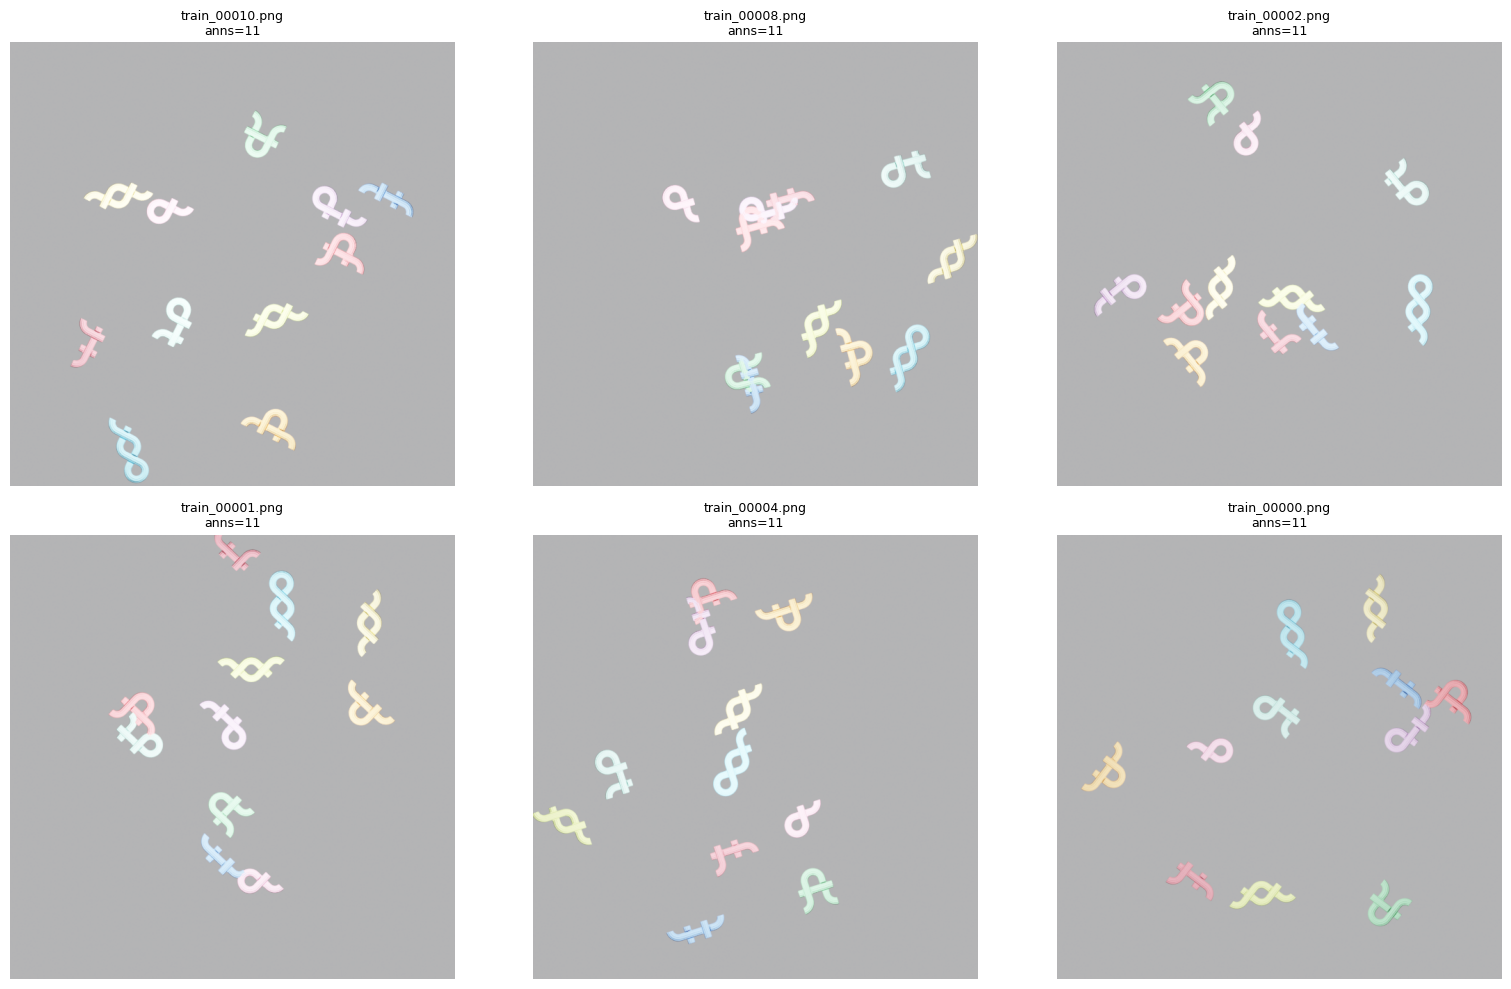

✅ Generation snapshot checkpoint complete


In [67]:
# Visual checkpoint: dataset generation snapshot
for split in ['train', 'val']:
    img_dir = DATASET_DIR / 'images' / split
    lbl_dir = DATASET_DIR / 'labels' / split
    imgs = sorted(img_dir.glob('*.png'))
    lbls = sorted(lbl_dir.glob('*.txt'))
    non_empty = 0
    for lp in lbls:
        try:
            if lp.read_text().strip():
                non_empty += 1
        except Exception:
            pass
    pct = (100.0 * non_empty / len(lbls)) if lbls else 0.0
    print(f"{split}: {len(imgs)} images, {len(lbls)} labels, {non_empty} non-empty ({pct:.1f}%)")

train_imgs = sorted((DATASET_DIR / 'images' / 'train').glob('*.png'))
if not train_imgs:
    print('⚠️ No train images to preview yet.')
else:
    sample_imgs = random.sample(train_imgs, min(6, len(train_imgs)))
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, img_path in enumerate(sample_imgs):
        img = cv2.imread(str(img_path))
        if img is None:
            axes[i].set_title(f"{img_path.name}\n(load failed)", fontsize=9)
            axes[i].axis('off')
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        lbl_path = DATASET_DIR / 'labels' / 'train' / f"{img_path.stem}.txt"
        ann_count = 0
        if lbl_path.exists():
            ann_count = len([ln for ln in lbl_path.read_text().splitlines() if ln.strip()])

        axes[i].imshow(img)
        axes[i].set_title(f"{img_path.name}\nanns={ann_count}", fontsize=9)
        axes[i].axis('off')

    for j in range(len(sample_imgs), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    print('✅ Generation snapshot checkpoint complete')

In [66]:
# Small-batch metrics: non-empty label rate + per-image annotation counts
def _counts_for_split(split, n_expected):
    counts = []
    for i in range(n_expected):
        lp = DATASET_DIR / 'labels' / split / f"{split}_{i:05d}.txt"
        if not lp.exists():
            counts.append(None)
            continue
        lines = [ln for ln in lp.read_text().splitlines() if ln.strip()]
        counts.append(len(lines))
    return counts

for split, n_expected in [('train', SMALL_BATCH_TRAIN), ('val', SMALL_BATCH_VAL)]:
    counts = _counts_for_split(split, n_expected)
    valid = [c for c in counts if c is not None]
    non_empty = [c for c in valid if c > 0]
    non_empty_rate = (100.0 * len(non_empty) / len(valid)) if valid else 0.0
    print(f"{split}: files={len(valid)}/{n_expected}, non-empty={len(non_empty)}/{len(valid)} ({non_empty_rate:.1f}%)")
    print(f"{split} per-image annotation counts: {counts}")

train: files=12/12, non-empty=12/12 (100.0%)
train per-image annotation counts: [11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11]
val: files=4/4, non-empty=4/4 (100.0%)
val per-image annotation counts: [11, 11, 11, 11]


## Section 5 — Dataset YAML

In [ ]:
# ── Write dataset.yaml ────────────────────────────────────────────────────────
yaml_content = f"""# IQ Noodles Synthetic Segmentation Dataset
# Generated by 01_generate_synthetic_data.ipynb

path: {DATASET_DIR.resolve()}
train: images/train
val: images/val

nc: 11

names:
"""
for cls_id, name in CLASS_NAMES.items():
    yaml_content += f"  {cls_id}: {name}\n"

yaml_path = DATASET_DIR / 'dataset.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

# ── Write classes.txt ──────────────────────────────────────────────────────────
classes_path = DATASET_DIR / 'classes.txt'
with open(classes_path, 'w') as f:
    for cls_id in sorted(CLASS_NAMES.keys()):
        f.write(f"{CLASS_NAMES[cls_id]}\n")

print(f"✅ Dataset YAML: {yaml_path}")
print(f"✅ Classes file: {classes_path}")
print()
print(yaml_content)

## Section 6 — Validation & Preview

In [39]:
from collections import Counter

OVERLAP_PIXEL_THRESHOLD = 4


def _find_duplicate_cells(nb_path):
    raw = json.loads(Path(nb_path).read_text())
    seen = {}
    duplicates = []
    for idx, cell in enumerate(raw.get('cells', []), start=1):
        src = ''.join(cell.get('source', [])).strip()
        if not src:
            continue
        key = (cell.get('cell_type'), src)
        if key in seen:
            duplicates.append((seen[key], idx))
        else:
            seen[key] = idx
    return duplicates


def _parse_label_line(line):
    parts = line.strip().split()
    if len(parts) < 9 or (len(parts) - 1) % 2 != 0:
        return None
    cls_id = int(parts[0])
    coords = np.array([float(v) for v in parts[1:]], dtype=np.float32).reshape(-1, 2)
    return cls_id, coords


def _split_metrics(split):
    img_dir = DATASET_DIR / 'images' / split
    lbl_dir = DATASET_DIR / 'labels' / split
    imgs = sorted(img_dir.glob(f'{split}_*.png'))
    lbls = sorted(lbl_dir.glob(f'{split}_*.txt'))

    overlap_violations = 0
    boundary_violations = 0
    non_empty_labels = 0
    class_freq = Counter()

    for lbl_path in lbls:
        lines = [ln.strip() for ln in lbl_path.read_text().splitlines() if ln.strip()]
        if lines:
            non_empty_labels += 1

        masks = []
        for line in lines:
            parsed = _parse_label_line(line)
            if parsed is None:
                continue
            cls_id, coords = parsed
            class_freq[cls_id] += 1

            if np.any(coords < 0.0) or np.any(coords > 1.0):
                boundary_violations += 1
            coords = np.clip(coords, 0.0, 1.0)

            pts = np.round(coords * (IMG_SIZE - 1)).astype(np.int32)
            if pts.shape[0] < 4:
                continue
            m = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
            cv2.fillPoly(m, [pts], 1)
            masks.append(m)

        for i in range(len(masks)):
            for j in range(i + 1, len(masks)):
                inter = int(np.count_nonzero((masks[i] & masks[j]) > 0))
                if inter > OVERLAP_PIXEL_THRESHOLD:
                    overlap_violations += 1

    return {
        'images': len(imgs),
        'labels': len(lbls),
        'non_empty_labels': non_empty_labels,
        'overlap_violations': overlap_violations,
        'boundary_violations': boundary_violations,
        'class_freq': class_freq,
    }


def _estimate_saturation_on_annotations(split, sample_n=8):
    img_dir = DATASET_DIR / 'images' / split
    lbl_dir = DATASET_DIR / 'labels' / split
    imgs = sorted(img_dir.glob(f'{split}_*.png'))
    if not imgs:
        return 0.0

    sample_imgs = random.sample(imgs, min(sample_n, len(imgs)))
    sat_vals = []

    for img_path in sample_imgs:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        sat = hsv[:, :, 1].astype(np.float32) / 255.0

        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        if not lbl_path.exists():
            continue

        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        for line in lbl_path.read_text().splitlines():
            parsed = _parse_label_line(line)
            if parsed is None:
                continue
            _, coords = parsed
            pts = np.round(np.clip(coords, 0.0, 1.0) * (img.shape[1] - 1)).astype(np.int32)
            if pts.shape[0] >= 4:
                cv2.fillPoly(mask, [pts], 1)

        if mask.sum() > 0:
            sat_vals.append(float(sat[mask > 0].mean()))

    if not sat_vals:
        return 0.0
    return float(np.mean(sat_vals))


# 1) Duplicate-cell audit
nb_path = NOTEBOOK_DIR / '01_generate_synthetic_data.ipynb'
duplicates = _find_duplicate_cells(nb_path)
print(f"Duplicate notebook cells: {len(duplicates)}")
if duplicates:
    print(f"  duplicate pairs (1-based): {duplicates[:8]}")
else:
    print("  ✅ No duplicate cells detected")

# 2-4) Annotation visibility + overlap + boundary checks
for split in ['train', 'val']:
    m = _split_metrics(split)
    print(f"\n{split}: images={m['images']} labels={m['labels']} non_empty={m['non_empty_labels']}")
    print(f"  overlap violations (> {OVERLAP_PIXEL_THRESHOLD}px): {m['overlap_violations']}")
    print(f"  boundary violations: {m['boundary_violations']}")
    if m['labels'] > 0:
        print(f"  annotation visibility: {100.0 * m['non_empty_labels'] / m['labels']:.1f}% non-empty label files")

# 5) Color wash-out check (mean saturation on annotated regions)
train_sat = _estimate_saturation_on_annotations('train', sample_n=8)
val_sat = _estimate_saturation_on_annotations('val', sample_n=8)
print(f"\nMean saturation on annotated pixels: train={train_sat:.3f}, val={val_sat:.3f}")
if train_sat < 0.18 or val_sat < 0.18:
    print("⚠️ Saturation appears low; investigate render lighting/color space further.")
else:
    print("✅ Saturation check passed (no obvious washed-out effect).")

# Keep sampled class-frequency report
train_labels = sorted((DATASET_DIR / 'labels' / 'train').glob('train_*.txt'))
sample_files = random.sample(train_labels, min(10, len(train_labels)))
class_freq = Counter()
for lbl_file in sample_files:
    with open(lbl_file) as f:
        for line in f:
            parsed = _parse_label_line(line)
            if parsed is None:
                continue
            cls_id, _ = parsed
            class_freq[cls_id] += 1

print(f"\nClass frequency (sampled):")
for cls_id in sorted(class_freq.keys()):
    print(f"  {cls_id:2d} ({CLASS_NAMES.get(cls_id, '?')}): {class_freq[cls_id]}")

Duplicate notebook cells: 0
  ✅ No duplicate cells detected

train: images=12 labels=12 non_empty=12
  overlap violations (> 4px): 0
  boundary violations: 0
  annotation visibility: 100.0% non-empty label files

val: images=4 labels=4 non_empty=4
  overlap violations (> 4px): 0
  boundary violations: 0
  annotation visibility: 100.0% non-empty label files

Mean saturation on annotated pixels: train=0.276, val=0.292
✅ Saturation check passed (no obvious washed-out effect).

Class frequency (sampled):
   0 (A_YellowGreen): 10
   1 (B_Red): 10
   2 (C_DarkBlue): 10
   3 (D_Purple): 10
   4 (E_Orange): 10
   5 (F_SkyBlue): 10
   6 (G_Green): 10
   7 (H_DarkRed): 10
   8 (I_Yellow): 10
   9 (J_Pink): 10
  10 (K_Teal): 10


✅ Preview saved to /home/salumi/projects/project/data/noodles_seg_dataset/preview.jpg


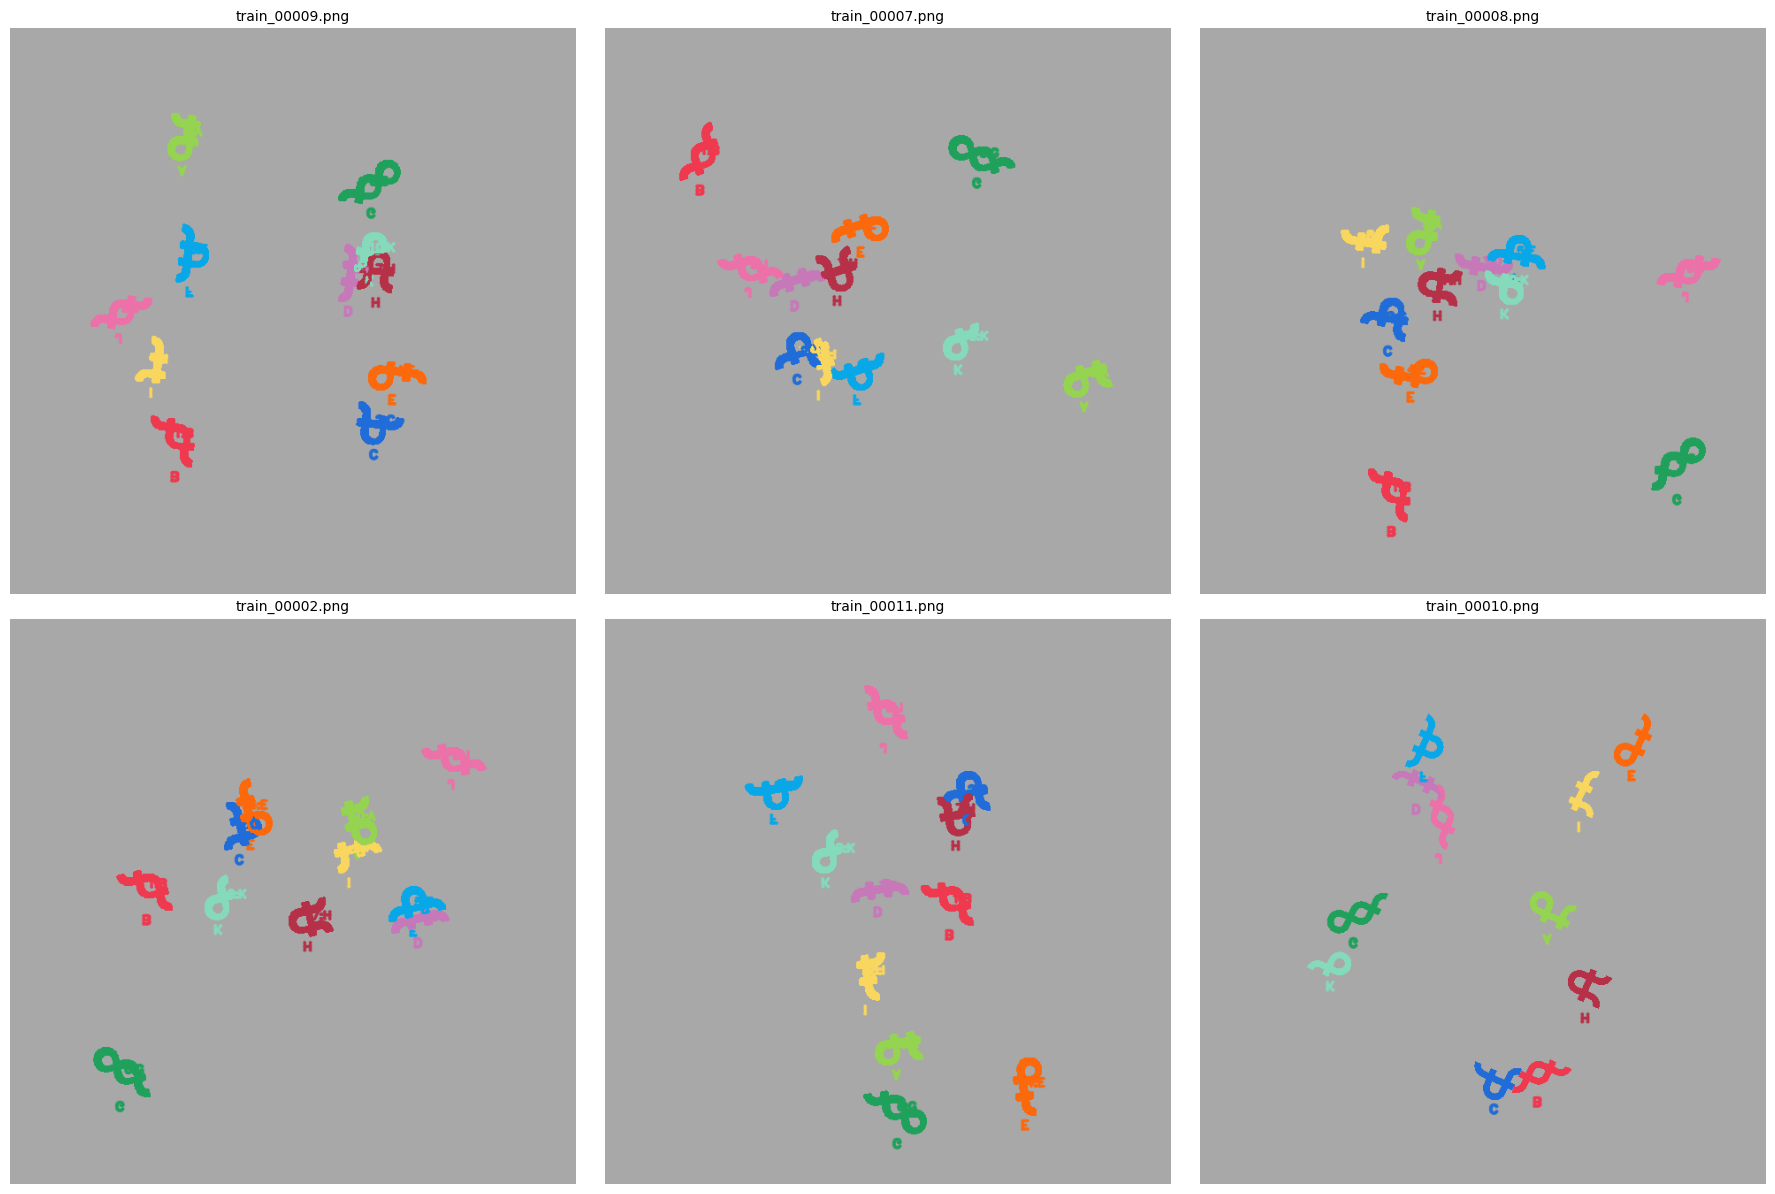

In [30]:
# ── Preview: draw polygons on sample images + class labels ─────────────────────
palette_rgb = [tuple(int(255 * c) for c in PIECE_COLORS_LINEAR[lbl]) for lbl in PIECE_LABELS]

train_imgs = sorted((DATASET_DIR / 'images' / 'train').glob('*.png'))
sample_imgs = random.sample(train_imgs, min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax_idx, img_path in enumerate(sample_imgs):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    lbl_path = DATASET_DIR / 'labels' / 'train' / (img_path.stem + '.txt')
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 9:
                    continue
                cls_id = int(parts[0])
                coords = [float(x) for x in parts[1:]]
                points = []
                for j in range(0, len(coords), 2):
                    px = int(np.clip(coords[j], 0.0, 1.0) * (w - 1))
                    py = int(np.clip(coords[j + 1], 0.0, 1.0) * (h - 1))
                    points.append([px, py])
                points = np.array(points, dtype=np.int32)
                color = palette_rgb[cls_id % len(palette_rgb)]
                cv2.polylines(img, [points], True, color, 2)

                centroid = points.mean(axis=0).astype(int)
                text = f"{cls_id}:{PIECE_LABELS[cls_id]}" if cls_id < len(PIECE_LABELS) else str(cls_id)
                cv2.putText(
                    img,
                    text,
                    (int(centroid[0]), int(centroid[1])),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.42,
                    color,
                    2,
                    cv2.LINE_AA,
                )

    axes[ax_idx].imshow(img)
    axes[ax_idx].set_title(img_path.name, fontsize=10)
    axes[ax_idx].axis('off')

for i in range(len(sample_imgs), len(axes)):
    axes[i].axis('off')

plt.tight_layout()

preview_path = DATASET_DIR / 'preview.jpg'
plt.savefig(str(preview_path), dpi=100, bbox_inches='tight')
print(f"✅ Preview saved to {preview_path}")
plt.show()